In [11]:
!pip install akshare

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ----------------------------- ---------- 0.8/1.1 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 2.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.5 MB 2.4 MB/s eta 0:00:07
   -- ------------------------------------- 1.0/15.5 MB 2.9 MB/s eta 0:00:05
   ---- ----------------------------------- 1.6/15.5 MB 3.0 MB/s eta 0:00:05
   ------ --------------------------------- 2.4/15.5 MB 3.0 MB/s eta 0:00:05
   -------- ------------------------------- 3.1/15.5 MB 3.2 MB/s eta 0:00:04
   ---------- -

  DEPRECATION: Building 'jsonpath' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'jsonpath'. Discussion can be found at https://github.com/pypa/pip/issues/6334


正在同步美股行情数据...


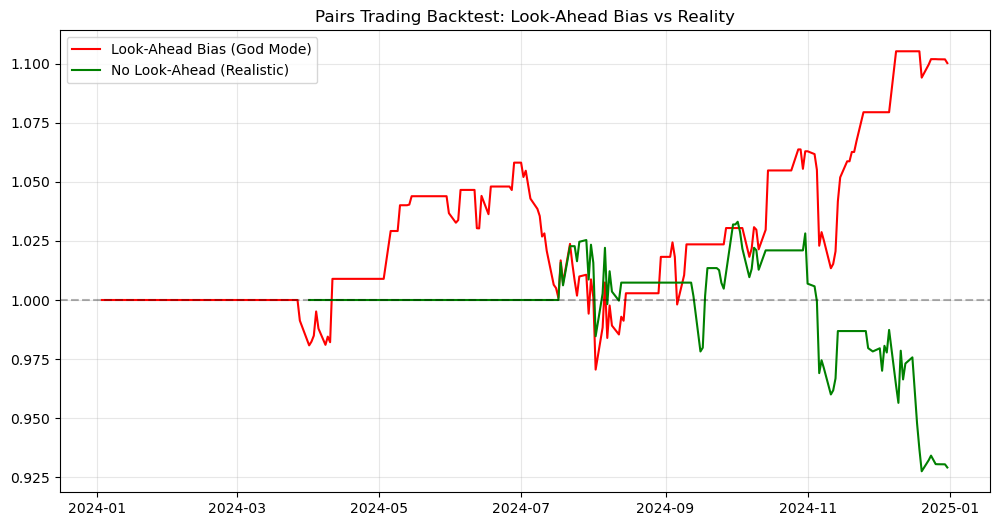

In [28]:
import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 数据获取
# =========================
def get_data(symbol):
    df = ak.stock_us_daily(symbol=symbol, adjust="")[['date', 'close']]
    df.columns = ['Date', symbol]
    df['Date'] = pd.to_datetime(df['Date'])
    return df.set_index('Date').sort_index()

print("正在同步美股行情数据...")
aapl = get_data("AAPL")
qqq = get_data("QQQ")

df = (
    pd.concat([aapl, qqq], axis=1)
    .dropna()
    .loc['2024-01-01':'2024-12-31']
)

# =========================
# 2. OLS 回归（手写）
# =========================
def ols_beta(y, x):
    """
    y = alpha + beta * x
    return: alpha, beta
    """
    X = np.column_stack([np.ones(len(x)), x])
    try:
        alpha, beta = np.linalg.inv(X.T @ X) @ X.T @ y
        return alpha, beta
    except np.linalg.LinAlgError:
        return np.nan, np.nan

# =========================
# 3. 残差计算
# =========================
# 3.1 错误示例：全样本回归（Look-Ahead Bias）
alpha_all, beta_all = ols_beta(df['AAPL'].values, df['QQQ'].values)
df['res_bias'] = df['AAPL'] - (beta_all * df['QQQ'] + alpha_all)

# 3.2 正确示例：滚动回归
window = 60
df['res_correct'] = np.nan

for i in range(window, len(df)):
    y = df['AAPL'].iloc[i-window:i].values
    x = df['QQQ'].iloc[i-window:i].values
    alpha, beta = ols_beta(y, x)

    df.iloc[i, df.columns.get_loc('res_correct')] = (
        df['AAPL'].iloc[i] - (beta * df['QQQ'].iloc[i] + alpha)
    )

# =========================
# 4. 配对交易回测
# =========================
def backtest_pairs(residual, aapl, qqq, window=60):
    df_bt = pd.DataFrame({
        'res': residual,
        'AAPL': aapl,
        'QQQ': qqq
    }).dropna()

    # z-score（只用历史）
    mean = df_bt['res'].rolling(window).mean()
    std = df_bt['res'].rolling(window).std()
    df_bt['z'] = (df_bt['res'] - mean) / std

    # 仓位：只做 AAPL，多空对冲 QQQ
    df_bt['pos'] = 0
    df_bt.loc[df_bt['z'] < -1, 'pos'] = 1
    df_bt.loc[df_bt['z'] > 1, 'pos'] = -1

    # 日收益
    ret_aapl = df_bt['AAPL'].pct_change()
    ret_qqq = df_bt['QQQ'].pct_change()

    df_bt['strategy_ret'] = (
        df_bt['pos'].shift(1) * (ret_aapl - ret_qqq)
    )

    df_bt['equity'] = (1 + df_bt['strategy_ret']).cumprod()
    return df_bt

# =========================
# 5. 回测对比
# =========================
bt_bias = backtest_pairs(
    df['res_bias'],
    df['AAPL'],
    df['QQQ']
)

bt_correct = backtest_pairs(
    df['res_correct'],
    df['AAPL'],
    df['QQQ']
)

plt.figure(figsize=(12, 6))
plt.plot(bt_bias['equity'], label='Look-Ahead Bias (God Mode)', color='red')
plt.plot(bt_correct['equity'], label='No Look-Ahead (Realistic)', color='green')
plt.axhline(1, color='black', linestyle='--', alpha=0.3)
plt.title('Pairs Trading Backtest: Look-Ahead Bias vs Reality')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
